In [1]:
import yfinance as yf
import pandas as pd

# Johnson & Johnson Common Stock (JNJ)

## Collecting data

In [2]:
# Ticker
ticker = "JNJ"

# Create a Ticker object
jnj = yf.Ticker(ticker)

In [16]:
'''Date:  from 2022-03-17 to 2022-12-31'''
'''Interval: daily data'''
data_jn = jnj.history(start="2022-03-17", end="2022-12-31", interval="1d")


## Descriptive statistics

In [18]:
print(data_jn.head())

                                 Open        High         Low       Close  \
Date                                                                        
2022-03-17 00:00:00-04:00  156.012168  157.463559  155.112826  157.427948   
2022-03-18 00:00:00-04:00  157.606024  157.606024  154.631993  155.682693   
2022-03-21 00:00:00-04:00  155.522393  157.748466  155.219650  156.564194   
2022-03-22 00:00:00-04:00  156.564238  157.045064  154.854615  155.825180   
2022-03-23 00:00:00-04:00  156.029985  156.306016  155.014896  155.237503   

                             Volume  Dividends  Stock Splits  
Date                                                          
2022-03-17 00:00:00-04:00   7472100        0.0           0.0  
2022-03-18 00:00:00-04:00  13809500        0.0           0.0  
2022-03-21 00:00:00-04:00   7574900        0.0           0.0  
2022-03-22 00:00:00-04:00   8442100        0.0           0.0  
2022-03-23 00:00:00-04:00   5254200        0.0           0.0  


### Extract only the opening and closing price columns

In [19]:
# Extract only the opening and closing price columns
open_prices = data_jn["Open"]
close_prices = data_jn["Close"]

jn_open_close = pd.DataFrame({"Date": open_prices.index, "Open": open_prices.values, "Close": close_prices.values})
jn_open_close.reset_index(drop=True, inplace=True)
print(jn_open_close.head())

                       Date        Open       Close
0 2022-03-17 00:00:00-04:00  156.012168  157.427948
1 2022-03-18 00:00:00-04:00  157.606024  155.682693
2 2022-03-21 00:00:00-04:00  155.522393  156.564194
3 2022-03-22 00:00:00-04:00  156.564238  155.825180
4 2022-03-23 00:00:00-04:00  156.029985  155.237503


### Extract only the closing price columns

In [20]:
# Extract only the closing price column
close_prices = data_jn["Close"]

jn_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
jn_close.reset_index(drop=True, inplace=True)

print(jn_close.head())

                       Date       Close
0 2022-03-17 00:00:00-04:00  157.427948
1 2022-03-18 00:00:00-04:00  155.682693
2 2022-03-21 00:00:00-04:00  156.564194
3 2022-03-22 00:00:00-04:00  155.825180
4 2022-03-23 00:00:00-04:00  155.237503


In [21]:
data_jn.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.0
mean,155.831402,157.040110,154.585702,155.844660,7.024764e+06,0.016950,0.0
std,5.039106,4.985408,5.019723,5.049654,2.539403e+06,0.137699,0.0
min,144.681419,145.502384,143.598779,144.528015,2.645400e+06,0.000000,0.0
25%,151.063211,152.513763,149.832046,151.596588,5.512150e+06,0.000000,0.0
50%,156.668099,157.875701,155.499271,156.892334,6.426900e+06,0.000000,0.0
75%,159.836057,161.033018,158.751702,159.901588,7.894000e+06,0.000000,0.0
max,164.818511,166.234299,163.999304,165.628799,2.020150e+07,1.130000,0.0


In [22]:
data_jn.shape

(200, 7)

In [23]:
data_jn.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 200 entries, 2022-03-17 00:00:00-04:00 to 2022-12-30 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          200 non-null    float64
 1   High          200 non-null    float64
 2   Low           200 non-null    float64
 3   Close         200 non-null    float64
 4   Volume        200 non-null    int64  
 5   Dividends     200 non-null    float64
 6   Stock Splits  200 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 12.5 KB


In [24]:
data_jn.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

## KPIs

### Completeness

In [25]:
missing_values_count = data_jn.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [26]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(data_jn)

missing_info = pd.DataFrame({
    'missing_count': data_jn.isnull().sum(),
    'missing_percentage': (data_jn.isnull().sum() / total_rows) * 100
})

print(missing_info)

              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


### Latency

In [28]:
'''2.1 minimum and Maxmimum Close Price'''
min_close = data_jn['Close'].min()
max_close = data_jn['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")


Minimum Close Price: 144.52801513671875
Maximum Close Price: 165.62879943847656
Difference between Max and Min Close Price: 21.100784301757812


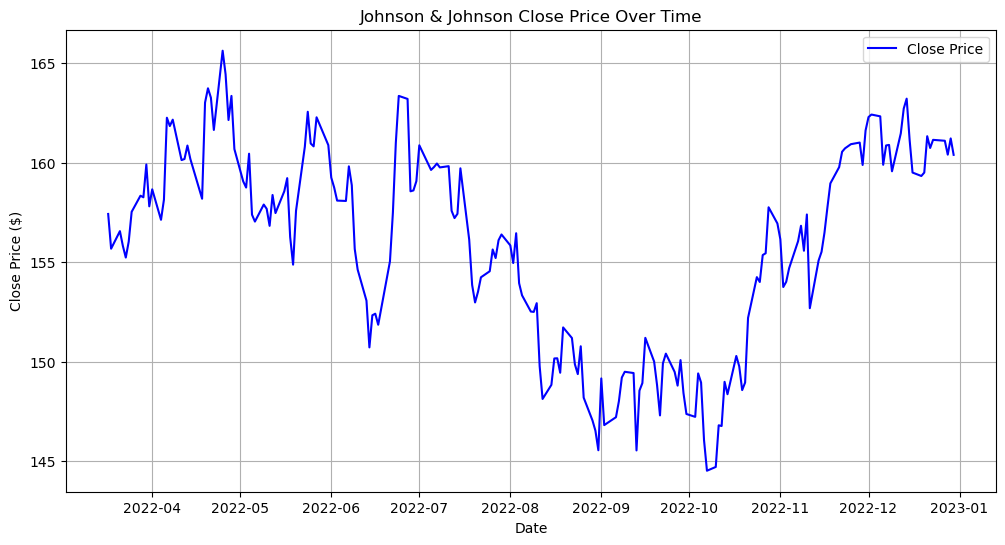

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
jn_close['Date'] = pd.to_datetime(jn_close['Date'])


# Set 'Date' as the index 
jn_close.set_index('Date', inplace=True)


# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(jn_close.index, jn_close['Close'], color='blue', label='Close Price')
plt.title('Johnson & Johnson Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### Consistency

In [30]:
print(data_jn.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [31]:
print(data_jn.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


### Error rate

In [33]:
# Missing rate
missing_rate = data_jn.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [34]:
# Duplicate rate
duplicate_rate = data_jn.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [35]:
# Outliers
Q1 = data_jn['Close'].quantile(0.25)
Q3 = data_jn['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data_jn['Close'] < Q1 - 1.5 * IQR) | (data_jn['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


## ACCURACY

In [36]:
valid_close = data_jn['Close'] > 0
valid_volume = data_jn['Volume'] > 0
valid_dividends = data_jn['Dividends'] >= 0

accurate_records = data_jn[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data_jn)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [37]:
invalid_records = data_jn[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data_jn)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")

❌ Invalid Value Rate: 0.00%


In [38]:
duplicate_rows = data_jn.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data_jn)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [39]:
unit_price_accuracy = (data_jn['Close'] > 0).sum() / len(data_jn) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
